In [68]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import math as m
from turnpike import solve_incomplete_turnpike
from turnpike_combined import solve_turnpike_combined

# 1-Qubit case

In [69]:
class LSZ_experiment():

    def __init__(self, n_qubits, epsilon, H_target_dictionary, ramp_time, wait_time):
        '''
        Params:
        epsilon: Coefficient of X Hamiltonian
        alpha: Coefficient of target Hamiltonian
        total_time: Total time of the algorithm
        wait_time: Waiting time in the middle of the LSZ algorithm (0 if just doing LZ)
        max_s: maximum of s parameter. Will control slope of schedule
        '''

        self.n_qubits = n_qubits
        self.e = epsilon
        self.Ht_dict = H_target_dictionary

        self.to =  0
        self.tw = wait_time
        self.tr = ramp_time
        
        self.tf = 2*self.tr + self.tw
       
        self.slope = 1/self.tr

        self.npsx, self.npsy, self.npsz = np.array([[0, 1], [1, 0]]), np.array([[0, -1j], [1j, 0]]), np.array([[1, 0], [0, -1]])
        self.qtsx, self.qtsy, self.qtsz = qt.sigmax(), qt.sigmay(), qt.sigmaz() 

        self.ket0 = qt.basis(2, 0)
        self.ket1 = qt.basis(2, 1)


        self.qtsx_list, self.qtsy_list, self.qtsz_list = self.initialize_qt_operators()
        self.npsx_list, self.npsy_list, self.npsz_list = self.initialize_np_operators()

        self.H0_numpy = self.build_H0_numpy()
        self.H0_qutip = self.build_H0_qutip()

        self.Ht_numpy = self.build_Ht_numpy()
        self.Ht_qutip = self.build_Ht_qutip()

    
    def kron_n(self, ops):
        '''Tensor product of a list of operators'''
        out = ops[0]
        for A in ops[1:]:
            out = np.kron(out, A)
        return out
    
    def build_H0_numpy(self):
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        for i in range(self.n_qubits):
            H += -self.e*self.npsx_list[i]
        return H

    def build_H0_qutip(self):
        H = 0
        for i in range(self.n_qubits):
            H += -self.e*self.qtsx_list[i]
        return H
    
    def build_Ht_numpy(self):
        #Initialize Hamiltonian
        H = np.zeros((2**self.n_qubits, 2**self.n_qubits))
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.npsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs 
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.npsz_list[i] @ self.npsz_list[j]
                    k += 1

        return H

    def build_Ht_qutip(self):
        #Initialize Hamiltonian
        H = 0
        local_z_terms = self.Ht_dict['one_body']

        #Add 1-body terms
        for i, weight in enumerate(local_z_terms):
            H += weight*self.qtsz_list[i]

        #Add 2-body terms only if more than 1 qubit
        if self.n_qubits > 1:
            zz_terms = self.Ht_dict['two_body']

            #Apply to all qubit pairs
            k = 0
            for i in range(self.n_qubits-1):
                for j in range(i+1, self.n_qubits):
                    H += zz_terms[k] * self.qtsz_list[i] * self.qtsz_list[j]
                    k += 1

        return H

    def initialize_np_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.npsx, self.npsy, self.npsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [np.eye(2) for _ in range(self.n_qubits)]
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(self.kron_n(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(self.kron_n(op_list))
            op_list[i] = sz
            sz_list.append(self.kron_n(op_list))

        return sx_list, sy_list, sz_list

    def initialize_qt_operators(self):
        '''Setup operators for individual qubits
            for each value of i it puts the paulis in different positions of the list, 
            then does IxIxI...sigma_ixIxI...xI
        '''
        sx_list, sy_list, sz_list = [], [], []
        sx, sy, sz = self.qtsx, self.qtsy, self.qtsz
        for i in range(self.n_qubits):
            #list of 2x2 identity matrices
            op_list = [qt.qeye(2)] * self.n_qubits
            #replace i-th element with sigma_x
            op_list[i] = sx
            #create matrices of 2^Nx2^N
            sx_list.append(qt.tensor(op_list))
            #do the same for sigma_y and sigma_z
            op_list[i] = sy
            sy_list.append(qt.tensor(op_list))
            op_list[i] = sz
            sz_list.append(qt.tensor(op_list))

        return sx_list, sy_list, sz_list


    def trapezoid_s(self, t):
        return np.minimum(1, self.slope * np.minimum(t, self.tf - t))

    def H_numpy(self, t):
        s = self.trapezoid_s(t)
        return (1-s)*self.H0_numpy + s*self.Ht_numpy
    
    def H_qutip(self):

        H = [[self.H0_qutip, lambda t, args: 1 - self.trapezoid_s(t)], [self.Ht_qutip, lambda t, args: self.trapezoid_s(t)]]

        return H
    
    
    def show_schedule(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        s_list = np.zeros(len(t_list))

        for i,t in enumerate(t_list):
            s_list[i] = self.trapezoid_s(t)
        
        return t_list, s_list
    
    def show_spectrum(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)
        eg_val_list = []
        eg_vec_list = []

       #Diagonalize for each time step 
        for i,t in enumerate(t_list):
            H = self.H_numpy(t)
            egvals, egvecs = np.linalg.eigh(H)

            eg_val_list.append(egvals)
            eg_vec_list.append(egvecs)

        return t_list, eg_val_list, eg_vec_list
    

    def time_evolution(self, n_steps):
        t_list = np.linspace(self.to, self.tf, n_steps)

        #Prepare ground state of H at time 0
        psi0 = qt.tensor([1/np.sqrt(2)*(self.ket0 + self.ket1)]*self.n_qubits)

        #Initialize qutip Hamiltonian
        H = self.H_qutip()

        #Time evolution
        return qt.sesolve(H, psi0, t_list)
    
    def calculate_populations(self, sim_res):

        final_state = sim_res.states[-1].full().flatten()

        H_f = self.H_numpy(self.tf)
        eigvals_f, eigvecs_f = np.linalg.eigh(H_f)

        # eigvecs_f columns are eigenvectors; eigvecs_f[:, k] is the k-th eigenvector
        n_states = 2**self.n_qubits
        populations = np.zeros(n_states)
        for k in range(n_states):
            overlap = np.dot(eigvecs_f[:, k].conj(), final_state)
            populations[k] = np.real(overlap * overlap.conj())

        return populations



- Ramp time controls the speed that we use to bring the system to the middle point. The faster, the higher the transition probability.

- High ramp time makes oscillations larger

- for LZ we ramp and pass the crossing once. For LZS you cross the gap twice. during wait time, s=1, no transverse term. Start at Hx, both terms evolve.

In [70]:
epsilon = 4
alpha = 0.25
ramp_time = 0.1
n_steps = 201

#1 qubit example
# local_z_list = np.array([1])
# zz_terms = np.array([])

#2 qubit example
# local_z_list = np.array([1.1,2.34])
# zz_terms = np.array([0.55])

#3 qubit example
local_z_list = np.array([2.1, 3.05, 1.78])
zz_terms = np.array([1.22, 0.54, 2.1])

#4 qubit example
# local_z_list = np.array([1.1, 2.05, 1.44, 0.93])
# zz_terms = np.array([2.82, 1.24, 0.36, 3.22, 1.48, 3.20])

nqubits = len(local_z_list)
max_wait_time = 50.0/alpha
n_sims = int(max_wait_time*20)

tw_l = np.linspace(0, max_wait_time, n_sims)
pc_list = []
pe_list = []


H_target_dict = {'one_body': local_z_list, 'two_body': zz_terms}

wait_test = 0
test =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_test)

print(max_wait_time)
print(n_sims)

200.0
4000


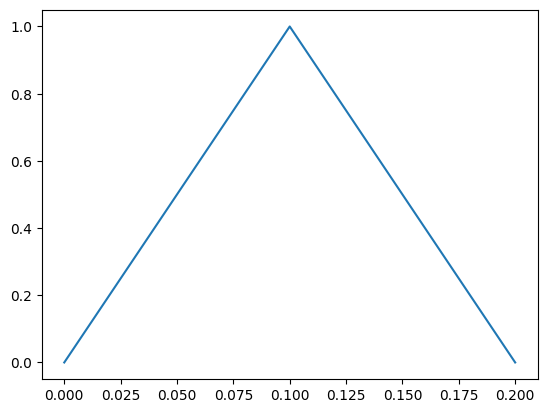

In [71]:
t_list, s_list = test.show_schedule(n_steps)
plt.plot(t_list, s_list)

[-4.79 -3.61 -3.07 -2.39 -1.95  1.95  3.07 10.79]


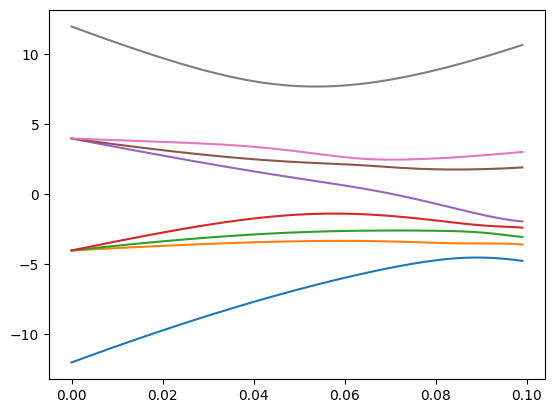

In [72]:
t_list, egvals, egvecs = test.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])

print(egvals[midpoint])

In [73]:
for wait_time in tw_l:
    experiment =LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, wait_time)

    n_steps = int((ramp_time*2 + wait_time)*51)
    
    result = experiment.time_evolution(n_steps)

    populations = experiment.calculate_populations(result)

    pc_list.append(np.real(populations[0]))

## Next steps:

0. Fixed code to do the right thing --DONE

1. Extract frequency and epsilon from oscillations --DONE

2. Test for 2 qubit system. Modify class to take in number of qubits external target Hamiltonian --DONE

3. Test interferometry for 2, 3 qubit systems --DONE

4. Look at ordering of energies, like how Matthias does it

4.1. Solve turnpike problem

4.2. Extract phases from Fourier analysis

In [74]:
def fourier_analysis(pc_list, tw_l, n_peaks=15, prominence_threshold=0.05):
    """
    Fourier analysis extracting all significant frequencies.
    
    Parameters
    ----------
    pc_list : array-like
        Signal (e.g. ground state population over time).
    tw_l : array-like
        Time axis.
    n_peaks : int
        Maximum number of peaks to return.
    prominence_threshold : float
        Peaks below this fraction of the dominant peak magnitude are ignored.
    
    Returns
    -------
    freqs_peaks : np.ndarray
        Frequencies of the identified peaks, sorted by magnitude (descending).
    amplitudes : np.ndarray
        Corresponding amplitudes.
    """
    from scipy.signal import find_peaks

    y = np.array(pc_list)
    t = np.array(tw_l)
    
    N = len(y)
    dt = t[1] - t[0]
    
    # FFT over positive frequencies only (skip DC at index 0)
    spectrum = np.fft.fft(y)
    freqs = np.fft.fftfreq(N, dt)
    magnitude = np.abs(spectrum)
    
    pos_idx = np.where(freqs > 0)[0]
    pos_freqs = freqs[pos_idx]
    pos_mag = magnitude[pos_idx]
    
    # Find all local peaks — low distance/prominence to avoid missing broad peaks
    peak_locs, _ = find_peaks(pos_mag, distance=1, prominence=0.01 * pos_mag.max())
    if len(peak_locs) == 0:
        peak_locs = np.array([np.argmax(pos_mag)])
    
    # Filter by prominence relative to the dominant peak
    threshold = prominence_threshold * pos_mag[peak_locs].max()
    peak_locs = peak_locs[pos_mag[peak_locs] >= threshold]
    
    # Sort by magnitude descending and take top n_peaks
    order = np.argsort(pos_mag[peak_locs])[::-1]
    peak_locs = peak_locs[order[:n_peaks]]
    
    freqs_peaks = pos_freqs[peak_locs]
    amplitudes = 2 * pos_mag[peak_locs] / N

    # x-axis: crop just past the highest detected frequency
    x_max = freqs_peaks.max() * 1.15

    # --- Plots ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(t, y, 'b-', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Signal')
    plt.title('Original Signal')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(pos_freqs, pos_mag, 'r-', linewidth=1.5)
    colors = plt.cm.tab10.colors
    # for i, (f, a) in enumerate(zip(freqs_peaks, amplitudes)):
    #     plt.axvline(f, color=colors[i % len(colors)], linestyle='--',
    #                 label=f'f{i+1}={f:.4f}, A={a:.4f}')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude')
    plt.xlim(0, x_max)
    plt.title('Fourier Transform')
    #plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Identified frequencies:")
    for i, (f, a) in enumerate(zip(freqs_peaks, amplitudes)):
        print(f"  f{i+1} = {f:.6f},  amplitude = {a:.6f}")
    
    return freqs_peaks, amplitudes


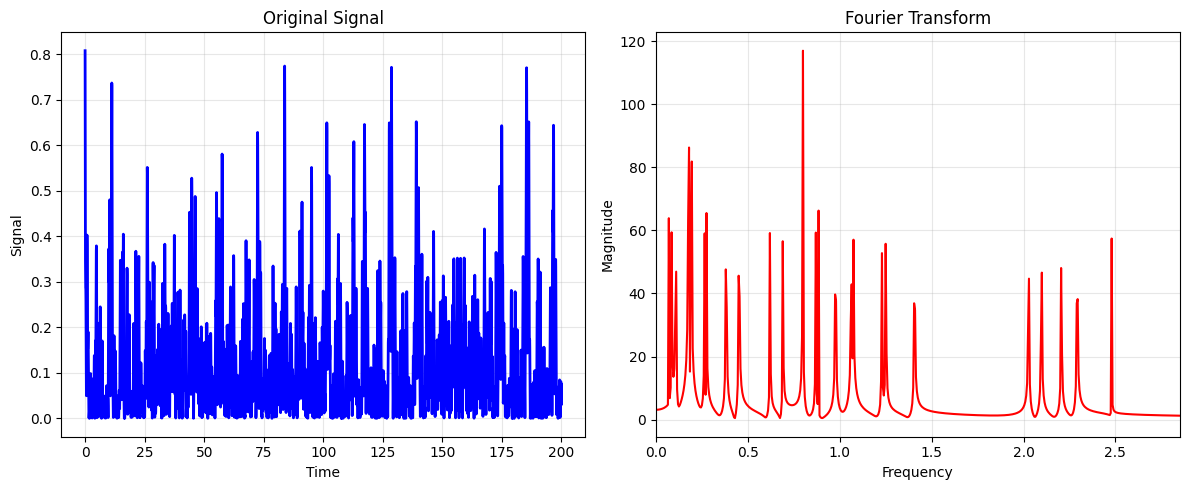

Identified frequencies:
  f1 = 0.799800,  amplitude = 0.058464
  f2 = 0.179955,  amplitude = 0.043120
  f3 = 0.194951,  amplitude = 0.040904
  f4 = 0.884779,  amplitude = 0.033124
  f5 = 0.274931,  amplitude = 0.032737
  f6 = 0.069983,  amplitude = 0.031918
  f7 = 0.084979,  amplitude = 0.029684
  f8 = 0.869782,  amplitude = 0.029641
  f9 = 0.619845,  amplitude = 0.029568
  f10 = 0.264934,  amplitude = 0.029519
  f11 = 2.479380,  amplitude = 0.028698
  f12 = 1.074731,  amplitude = 0.028513
  f13 = 0.689827,  amplitude = 0.028267
  f14 = 1.249687,  amplitude = 0.027864
  f15 = 1.229692,  amplitude = 0.026384
  f16 = 2.204449,  amplitude = 0.024024
  f17 = 0.379905,  amplitude = 0.023808
  f18 = 0.109973,  amplitude = 0.023451
  f19 = 2.099475,  amplitude = 0.023295
  f20 = 0.449887,  amplitude = 0.022804
  f21 = 2.029492,  amplitude = 0.022336
  f22 = 1.064734,  amplitude = 0.021443
  f23 = 0.974756,  amplitude = 0.019833
  f24 = 2.294426,  amplitude = 0.019093
  f25 = 1.404649,  amplit

In [75]:
freqs_peaks, amplitudes = fourier_analysis(pc_list, tw_l, n_peaks = m.factorial(2**nqubits -1))

f1: period = 1.250313,  recovered alpha = 5.025292  (amplitude = 0.058464)
f2: period = 5.556945,  recovered alpha = 1.130691  (amplitude = 0.043120)
f3: period = 5.129488,  recovered alpha = 1.224915  (amplitude = 0.040904)
f4: period = 1.130226,  recovered alpha = 5.559229  (amplitude = 0.033124)
f5: period = 3.637273,  recovered alpha = 1.727444  (amplitude = 0.032737)
f6: period = 14.289287,  recovered alpha = 0.439713  (amplitude = 0.031918)
f7: period = 11.767648,  recovered alpha = 0.533937  (amplitude = 0.029684)
f8: period = 1.149713,  recovered alpha = 5.465005  (amplitude = 0.029641)
f9: period = 1.613307,  recovered alpha = 3.894601  (amplitude = 0.029568)
f10: period = 3.774529,  recovered alpha = 1.664628  (amplitude = 0.029519)
f11: period = 0.403327,  recovered alpha = 15.578404  (amplitude = 0.028698)
f12: period = 0.930465,  recovered alpha = 6.752736  (amplitude = 0.028513)
f13: period = 1.449638,  recovered alpha = 4.334314  (amplitude = 0.028267)
f14: period = 0.80

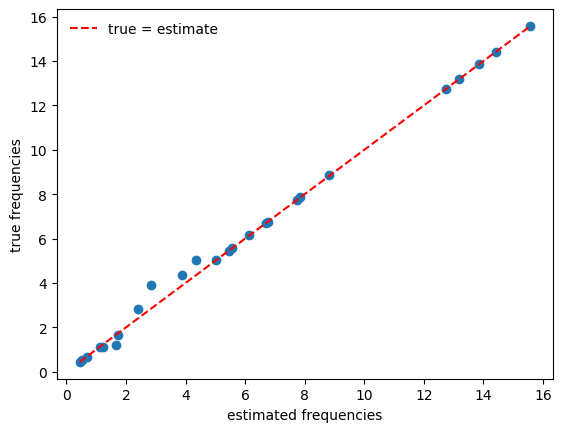

In [76]:
e_differences = []
for i, (f, a) in enumerate(zip(freqs_peaks, amplitudes)):
    print(f"f{i+1}: period = {1/f:.6f},  recovered alpha = {2*np.pi*f:.6f}  (amplitude = {a:.6f})")
    e_differences.append(2*np.pi*f)


print(egvals[midpoint])


true_differences = []
for i in range(len(egvals[midpoint])):
    for j in range(i+1, len(egvals[midpoint])):
        true_differences.append(egvals[midpoint][j] - egvals[midpoint][i])
        

start = len(true_differences) - len(e_differences)
plt.scatter(np.sort(e_differences), np.sort(true_differences[start:]))
diag = np.linspace(np.min(e_differences), np.max(e_differences), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated frequencies")
plt.ylabel("true frequencies")
plt.legend(frameon=False)

print(min(true_differences), min(e_differences))
print(max(true_differences), max(e_differences))


In [82]:
solutions = solve_incomplete_turnpike(e_differences, n_levels=2**nqubits)

Incomplete Turnpike Solver
  Target levels:       8
  Expected differences: 28
  Observed differences: 25 (89%)

  Trying match threshold = 100% ... no solution at this threshold.
  Trying match threshold = 80% ... 

ValueError: attempt to get argmin of an empty sequence

In [79]:
print(solutions)

{'levels': array([0.        , 0.57434684, 1.15001974, 1.7235942 , 2.61818813,
       3.57659157, 4.15016604, 4.72583894]), 'x': array([0.02507896, 0.02509875, 0.02511157, 0.02513439, 0.02520706,
       0.02538084, 0.02568813, 0.02611154, 0.02658061, 0.02700029,
       0.02728804, 0.02740361, 0.02736832, 0.02726093, 0.02718297,
       0.02721847, 0.02741177, 0.02775588, 0.02818701, 0.02860463,
       0.02892157, 0.02911073, 0.02921429, 0.02931712, 0.02950474,
       0.02981642, 0.03020903, 0.03056546, 0.03076087, 0.03074239,
       0.03055791, 0.03031504, 0.03011215, 0.02999857, 0.02998086,
       0.03004279, 0.03014652, 0.03022835, 0.03022548, 0.03012632,
       0.02998852, 0.02989959, 0.0299199 , 0.0300518 , 0.03024173,
       0.03040731, 0.03047574, 0.0304112 , 0.03022229, 0.02995758,
       0.02968771, 0.02946983, 0.02931518, 0.02918731, 0.02903178,
       0.02881698, 0.02856284, 0.02833677, 0.02821552, 0.02823948,
       0.02838929, 0.02859652, 0.0287835 , 0.02890843, 0.02898428,
 

In [80]:
real_vals = egvals[midpoint]
shifted_vals = [i - real_vals[0] for i in real_vals]
print('  '.join(f'{v:.3f}' for v in shifted_vals))
found_vals = solutions['levels']
print('  '.join(f'{v:.3f}' for v in found_vals))

0.000  1.180  1.720  2.400  2.840  6.740  7.860  15.580
0.000  0.574  1.150  1.724  2.618  3.577  4.150  4.726


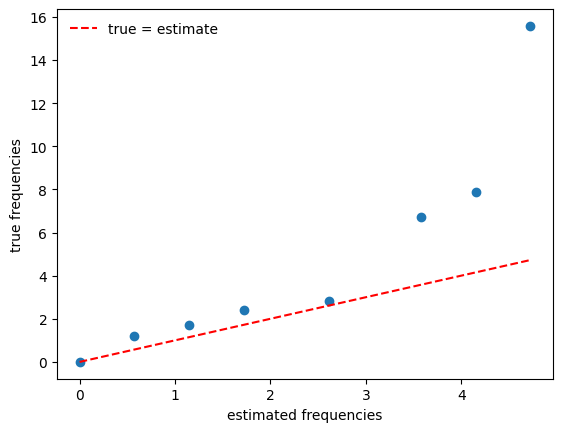

In [81]:

plt.scatter(np.sort(found_vals), np.sort(shifted_vals))
diag = np.linspace(np.min(found_vals), np.max(found_vals), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated frequencies")
plt.ylabel("true frequencies")
plt.legend(frameon=False)